# バリア関数と内点法について

バリア関数は制約条件を陽に


## 対数の性質

$\log_a(x) = b$ とは $a^b = x$ を満たす指数 $b$ のことである。<br>
例えば低数 $a$ を10とすると、$10^b = x$ ということから、xを正方方向から$0$に近づけていくと、

|$x$|$b$|
|---:|---:|
|100|10|
|10|1|
|0.1|-1|
|0.001|-3|
|0.00001|-5|

のように $-\infty$ に近づいていく。

これは $x \rightarrow 0^+$ のとき $log(x) \rightarrow -\infty$ と表記できる。

実際に図で描くと、正方向から0に近づけていく状況を見ると0付近で急激に下がっている。この図で気を付けることは負方向では logは実数では定義されない。これは制約条件を考えるときに気を付けるべきポイントである。

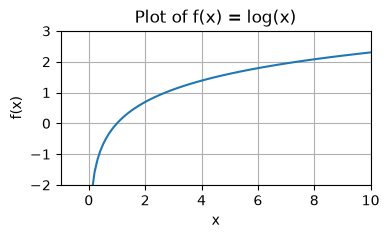

In [7]:
import matplotlib.pyplot as plt
import numpy as np

x = np.linspace(0.00001, 10, 100)
f = np.log(x)

fig, ax = plt.subplots(1,1, figsize=(4,2))
ax.plot(x, f)
ax.set_title('Plot of f(x) = log(x)')
ax.set_xlabel('x')
ax.set_ylabel('f(x)')
ax.set_xlim(-1, 10)
ax.set_ylim(-2, 3)
ax.grid()

## 解きたい問題

次の制約条件 $g(x) \le 0$ を満たす 目的関数 $f(x)$ を最小化する $x$ を求めたいという問題がある。

$$
\min_{x} f(x) \hspace{1em} \text{subject to} \hspace{1em} \space g(x) \le 0
$$

例えば $f(x) = x^2$ , $g(x) = x +1 \le 0$ というものである。この場合、$x=-1$という正解が導かれるが、これがもっと複雑になった場合、数値計算による方法が必要になる。<br>
制約条件を目的関数に組みこむ方法がバリア関数であり、そのバリア付き目的関数を数値的に解くアルゴリズムが内点法である。

## バリア関数

対数$\log(x)$の性質は上記で見た通り、 $x \rightarrow 0^+$ のとき $\log(x) = -\infty$ とうものである。また、$x \rightarrow 0^{-}$ と負側から $0$へ近づける場合は $\log(x)$ は実数では定義されない。

制約条件は $g(x) \le 0$ であり 許容境域で負または$0$となる。そのため $\log(g(x))$は実数では定義されない、ということなる。

そこで、$gg(x) = -g(x)$ として、制約条件 $g(x) \le 0$ を $gg(x) \ge 0$ へ書き換える。

また、最小化問題では制約の外側へ進まないように、境界へ近づくほど評価関数が無限大になるような関数を加える。それを対数関数$\log$で実現する。

$\log(gg)$ とすると制約の境界へ近づき、$gg(x) \rightarrow 0^+$ のとき $-\infty$ である。そのため最小化では境界へ積極的に近づく方向に働いてしまう。そこで $-\log(gg)$とすると$gg(x) \rightarrow 0^+$ で $+\infty$ となる。これをバリア関数と呼ぶ。

バリア関数を評価関数$f$を次のように組み込み、

$$
\bar{f}(x) = f(x) - \mu \log(gg(x))
$$

以下の制約なし問題に変換する。

$$
\min_{x} \bar{f}(x)  \hspace{1em}  \xcancel{\text{subject to} \hspace{1em} \space g(x) \le 0}
$$

ただし、$\log(gg)$は $gg > 0$ でのみ定義されるため、探索は常に制約の内側で行われる。



### バリア付き評価関数の停留条件

バリア関数付き評価関数は通常は数値計算によって解くが、その前に停留条件を解析的に導出してみよう。

ラグランジュの未定乗数法で見たように、停留条件を $\bar{f}(x)$ の一次変化がゼロとなる場所を探す。

そうすると、$f(x), gg(x) = - g(x)$ は多変数であるため、偏微分は $\nabla f, \nabla gg = -\nabla g$ となる。<br>
また$\log(x)$ の $x$による偏微分は $1/x$ である。今 $\log(gg(x))$ となっているため、チェインルールより、$\log(gg(x))$の$x$による偏微分は $1/gg(x) \nabla gg$となる。

$$
\nabla \log(gg(x)) = \frac{1}{gg(x)} \nabla gg \
$$

よって停留条件は以下となる。

$$
\nabla \bar{f} = \nabla f - \frac{\mu}{gg(x)} \nabla gg = \nabla f + \frac{\mu}{gg(x)} \nabla g = 0

$$ 

以下のように$\lambda$を設定すると、

$$
\boxed{
\lambda = \frac{\mu}{gg(x)}
}
$$

以下のようになる。これはKKTの停留条件である。

$$
\boxed{
\nabla \bar{f} = \nabla f + \lambda \nabla g = 0
}
$$ 

さらに、

$$
\lambda gg(x) = \mu
$$

で、$\mu \rightarrow 0$なら、以下となり、これはKKTにおける相補性条件である。

$$
\boxed{
\lambda gg(x) = 0
}
$$

$\lambda$ は $gg(x) \ge 0$ であるため、$\mu \ge 0$ ならは、$\lambda \ge 0$ となり、これもKKT条件の一つである。


このように、バリア関数のよる制約を加えた評価関数 $\bar{f}$ は $\mu \rightarrow 0$ の極限でKKT条件と一致する。

## 数値計算による最小化

### ニュートン法

ニュートン法はテイラー展開より導くことが出来る。

テイラー展開の3次以上の項を無視した2次近似の式は以下のようになる。これは1変数に場合で記述している。

$$
f_{II}(x + \Delta x) = f(x) + \frac{d f(x)}{d x} \Delta x + \frac{1}{2} \frac{d^2 f(x)}{d x^2} \Delta x^2
$$

この $f_{II}$ を $\Delta x$ で微分し停留条件を考えると、2次近似の停留点(極大、または極小)を求めることが出来る。

$$
\frac{d f(x)}{d x} + \frac{d^2 f(x)}{d x^2} \Delta x = 0
$$

テイラー展開の展開点を $x_k$ とすると $d f(x) / dx |_{x=x_k} = f'(x_k)$ , $d^2 f(x) / dx^2 |_{x=x_k}= f''(x_k)$は定数になり、$\Delta x$は変数となる。よって、展開点 $x_k$ から2次近似の停留点までの距離(更新量)は次のようになる。

$$
\Delta x = - \frac{f'(x_k)}{f''(x_k)}
$$

よって、これを初期値 $x_k$から繰り返していくと、$|\Delta x| < \varepsilon$ となる場所を極値として求めることが出来る。

処理のイメージは以下のようになる。展開点 $x_k$ におけるテイラー展開の2次近似を $f_{{II} \space k}$ として、$x_k$ から $f_{{II} \space k}$ の停留点までの距離 $\Delta x_k$ を求める。次に、$x_{k+1} = x_k + \Delta x_k$ として、その点の $f_{{II} \space k}+1$ の停留点までの距離 $\Delta x_{k+1}$ を求める、といったように繰り返していく。最終的に極値では $\Delta x_{k+n} \le \varepsilon$ と小さくなる。

<img src="images/newton_method_image.png" style="width:50%;">

バリア関数を組み込んだ評価関数 $\bar{f}$ のニュートン法を考える。

$$
\bar{f}(x) = f(x) - \mu \log(gg(x))
$$

$$
\begin{aligned}
\bar{f'(x)} &= f'(x) - \mu gg^{-1}(x) gg'(x) \\
\bar{f''(x)} &= f''(x) + \mu \frac{(gg'(x))^2}{gg(x)}  - \mu \frac{gg''(x)}{gg(x)}  \\
\end{aligned}
$$

となり、
$$
f'(x) - \mu \frac{gg'(x)}{gg(x)}  + \left( f''(x) + \mu \frac{(gg'(x))^2}{gg(x)}  - \mu \frac{gg''(x)}{gg(x)} \right)\Delta x
$$
